<h1>Machine Learning Regression</h1>

In [65]:
%pip install seaborn
%pip install matplotlib
%pip install pandas
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [66]:
import matplotlib
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [67]:
pd.set_option("display.max_columns", None)

In [68]:
#from pyodide.http import pyfetch
import requests

def download(url, filename):
    response = requests.get(url)
    print("Connection to url successsfull")
    try:
        if response.status_code == 200: 
            data = response.content
            with open(filename, "wb") as f: 
                f.write(data)
                print("Data successfully written")
    except Exception as e:
        print(f"Error: {e}")

In [69]:
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
filename = "fuelConsumption.csv"

In [70]:
download(url,filename)

Connection to url successsfull
Data successfully written


In [71]:
df = pd.read_csv(filename)
df.columns = df.columns.str.lower()
df.head()

,modelyear,make,model,vehicleclass,enginesize,cylinders,transmission,fueltype,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   modelyear                 1067 non-null   int64  
 1   make                      1067 non-null   object 
 2   model                     1067 non-null   object 
 3   vehicleclass              1067 non-null   object 
 4   enginesize                1067 non-null   float64
 5   cylinders                 1067 non-null   int64  
 6   transmission              1067 non-null   object 
 7   fueltype                  1067 non-null   object 
 8   fuelconsumption_city      1067 non-null   float64
 9   fuelconsumption_hwy       1067 non-null   float64
 10  fuelconsumption_comb      1067 non-null   float64
 11  fuelconsumption_comb_mpg  1067 non-null   int64  
 12  co2emissions              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [73]:
df.isnull().sum()

modelyear                   0
make                        0
model                       0
vehicleclass                0
enginesize                  0
cylinders                   0
transmission                0
fueltype                    0
fuelconsumption_city        0
fuelconsumption_hwy         0
fuelconsumption_comb        0
fuelconsumption_comb_mpg    0
co2emissions                0
dtype: int64

<h2>Exploratory Analysis</h2>

In [74]:
df.describe()

,modelyear,enginesize,cylinders,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


<h3>Distributions</h3>

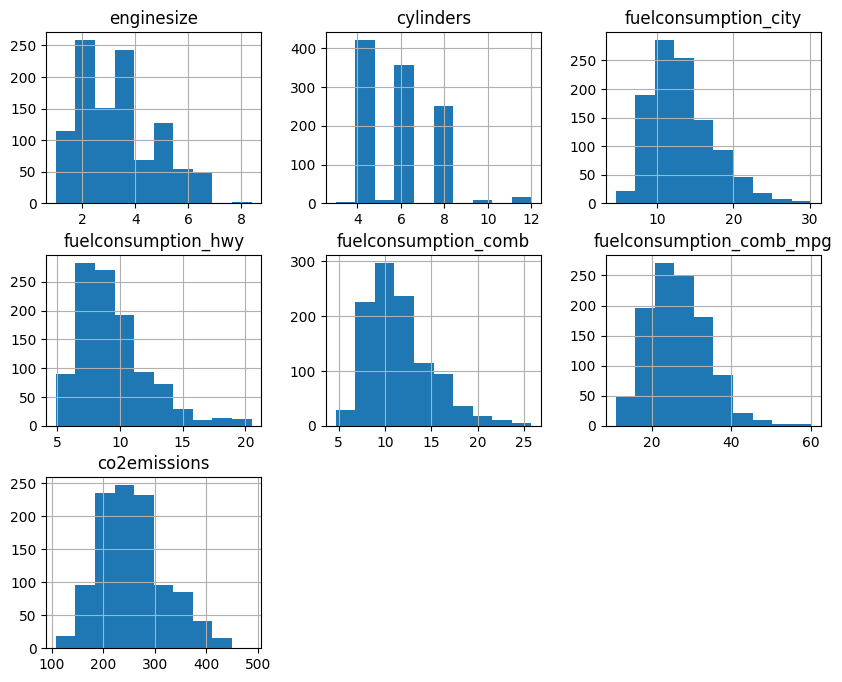

In [75]:
df_selection = df[["enginesize","cylinders", "fuelconsumption_city", "fuelconsumption_hwy","fuelconsumption_comb","fuelconsumption_comb_mpg","co2emissions"]]
df_selection.hist(figsize=(10,8))
plt.show()

<h3>Scatter Plots</h3>

In [76]:
text = "enginesize,cylinders,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg"
IV = text.split(",")
IV

['enginesize',
 'cylinders',
 'fuelconsumption_city',
 'fuelconsumption_hwy',
 'fuelconsumption_comb',
 'fuelconsumption_comb_mpg']

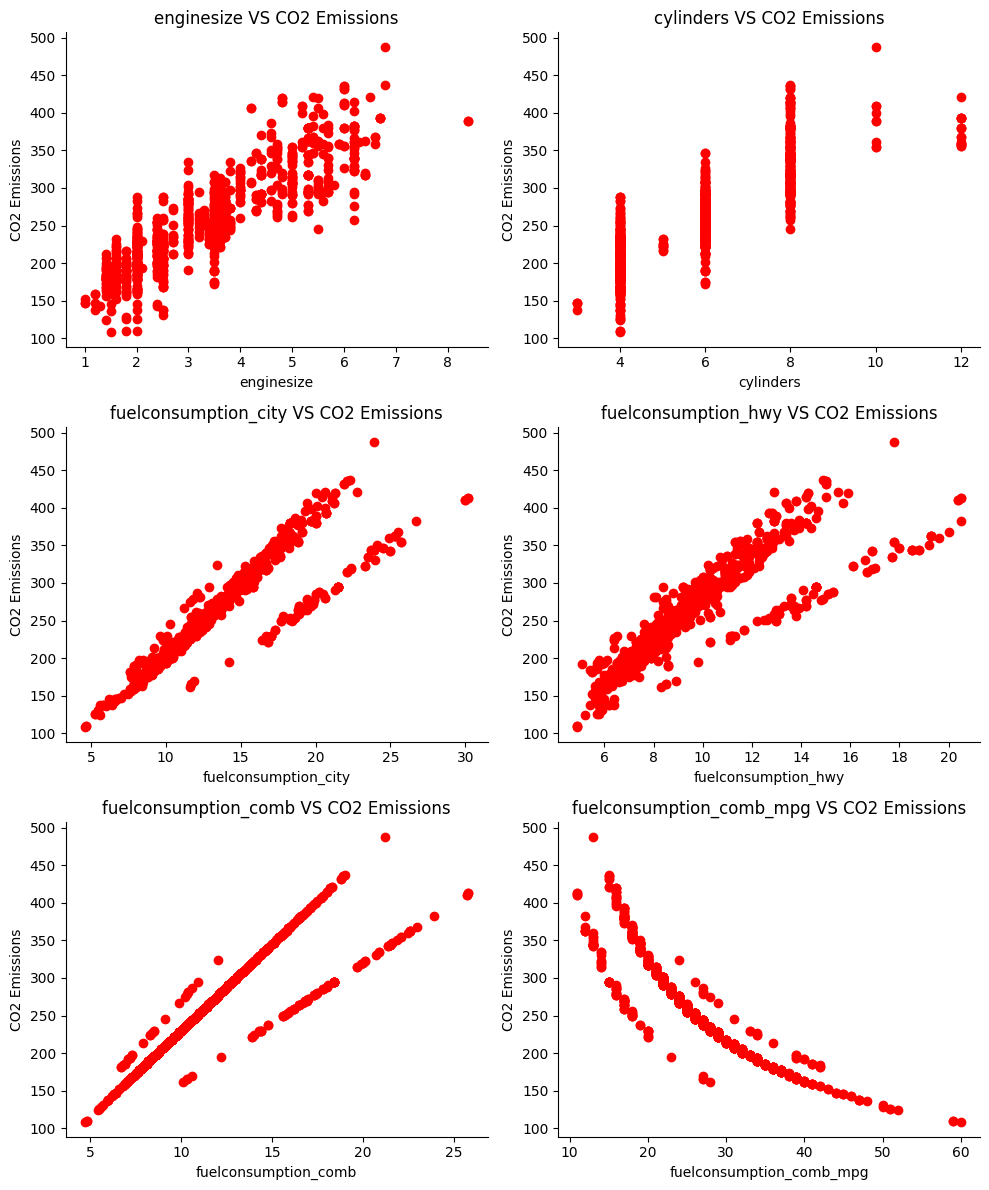

In [77]:
import math

ncol = 2
nrow = math.ceil(len(IV)/ncol)

fig, ax = plt.subplots(nrow, ncol, figsize=(10,12))

ax = ax.flatten()

for i, j in enumerate(IV):
    
    ax[i].scatter(x = j, y = "co2emissions", data = df, color = "red")
    ax[i].set_title(f"{j} VS CO2 Emissions")
    ax[i].set_xlabel(f"{j}") 
    ax[i].set_ylabel("CO2 Emissions")
    
sns.despine()
plt.tight_layout()
plt.show()

<h2>Simple Linear Regression</h2>

<h3>Effect of Engine Size on CO2 Emissions</h3>

In [78]:
X = df[['enginesize']] 
y = df['co2emissions']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state = 42)

In [80]:
print(X_train.shape, X_test.shape)

(853, 1) (214, 1)


In [81]:
model = LinearRegression()
model

LinearRegression()

In [82]:
model.fit(X_train, y_train)
a = model.coef_[0]
b = model.intercept_
R2 = model.score(X_train, y_train)
print(f" regression coefficient: a = {a:.2f}, intercept = {b:.2f}, R2 = {R2:.2f}")

 regression coefficient: a = 38.99, intercept = 126.29, R2 = 0.76


<h4>Regression and Residual Plot</h4>

Text(0.5, 1.1, 'Effect of Engine Size on CO2 Emission')

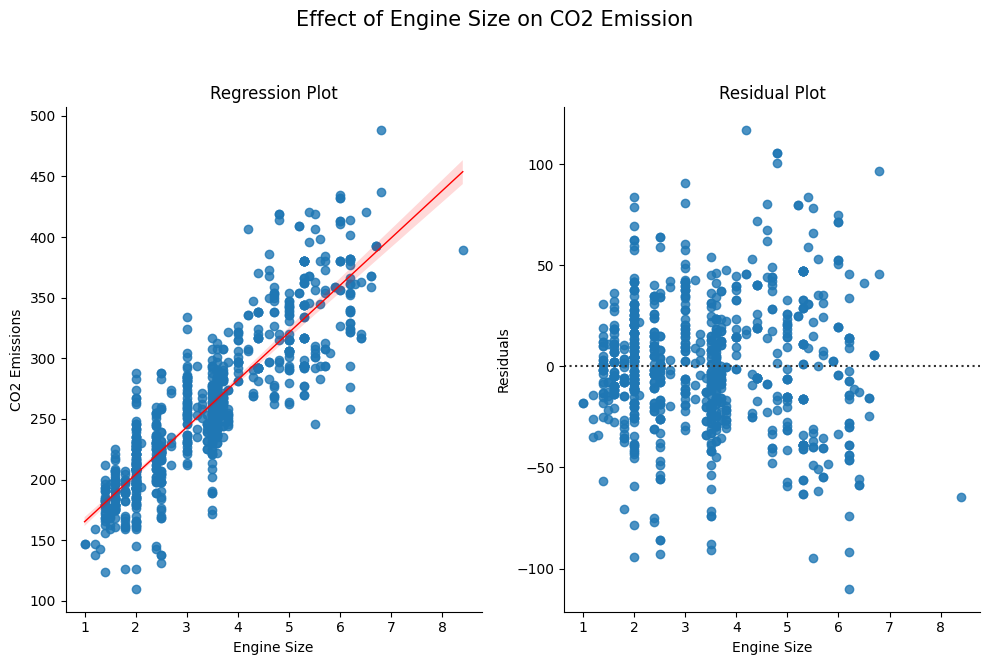

In [83]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,6))
sns.regplot(x = X_train, y = y_train, line_kws = ({"color":"red", "linewidth":1}), ax = ax1)
sns.residplot(x = X_train, y = y_train, ax = ax2)
ax1.set_title("Regression Plot")
ax2.set_title("Residual Plot")

ax1.set_xlabel("Engine Size")
ax1.set_ylabel("CO2 Emissions")

ax2.set_xlabel("Engine Size")
ax2.set_ylabel("Residuals")

sns.despine()
plt.tight_layout()
plt.suptitle("Effect of Engine Size on CO2 Emission", fontsize = 15, y = 1.1)

<h4>Model Evaluation</h4>

In [84]:
y_pred_train = model.predict(X_train)

In [85]:
MAE = mean_absolute_error(y_train, y_pred_train)
MSE = mean_squared_error(y_train, y_pred_train)
RMSE = root_mean_squared_error(y_train, y_pred_train)
R2 = r2_score(y_train, y_pred_train)
print(f"""for the training set: MAE = {MAE:.2f},
MSE = {MSE:.2f},
RMSE = {RMSE:.2f},
R2 = {R2:.2f}""")

for the training set: MAE = 23.20,
MSE = 936.79,
RMSE = 30.61,
R2 = 0.76


In [86]:
y_pred = model.predict(X_test)

In [87]:
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = root_mean_squared_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)
print(f"""for the testing set: MAE = {MAE:.2f},
MSE = {MSE:.2f},
RMSE = {RMSE:.2f},
R2 = {R2:.2f}""")

for the testing set: MAE = 24.10,
MSE = 985.94,
RMSE = 31.40,
R2 = 0.76


<h4>Regression and KDE plots</h4>

Text(0.5, 1.0, 'Effect of engine size on CO2 emissions')

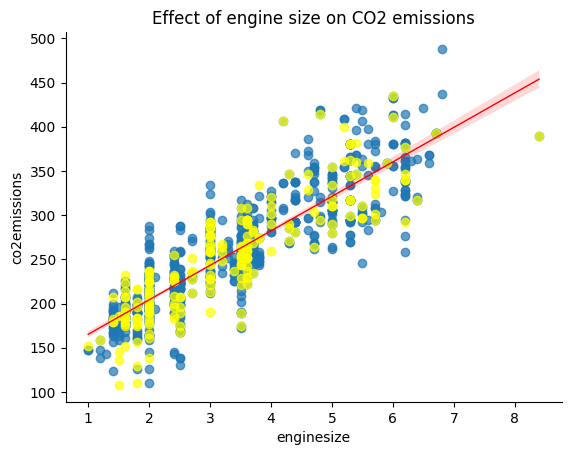

In [88]:
sns.regplot(x = X_train, y = y_train, line_kws = ({"color":"red", "linewidth":1}), scatter_kws = ({"alpha":.7}))
plt.scatter(X_test, y_test, color= "yellow", alpha = .7)
sns.despine()
plt.title("Effect of engine size on CO2 emissions")

Text(0.5, 1.0, 'Distribution of CO2 Emissions: Training vs Testing')

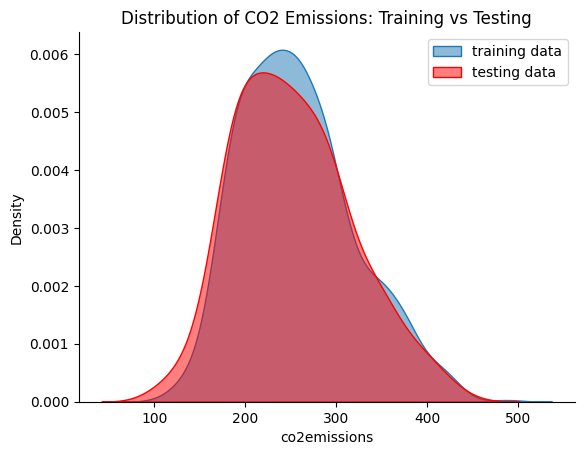

In [89]:
sns.kdeplot(y_train, fill = True, alpha = .5, label = "training data" )
sns.kdeplot(y_test, fill = True, color = "red", alpha = .5, label = "testing data")
plt.legend()
sns.despine()
plt.title("Distribution of CO2 Emissions: Training vs Testing")

<p>The linear regression model was evaluated using both the training and testing datasets to assess its performance and generalization ability. On the training set, the model achieved a Mean Absolute Error (MAE) of 23.20, a Mean Squared Error (MSE) of 936.79, a Root Mean Squared Error (RMSE) of 30.61, and an R² score of 0.76. On the testing set, the results were very similar, with an MAE of 24.10, an MSE of 985.94, an RMSE of 31.40, and an R² score of 0.76. The close similarity between training and testing metrics indicates that the model does not suffer from overfitting and generalizes well to unseen data. The R² value of 0.76 suggests that approximately 76% of the variability in CO₂ emissions is explained by the selected input features, indicating a reasonably strong linear relationship. Overall, the model provides stable and consistent predictions, though there is still some unexplained variance that could potentially be reduced by using additional features or more complex modeling techniques.</p>

<h3>Effect of Fuel Consumption Combined on CO2 Emissions</h3>

In [90]:
X = df[['fuelconsumption_comb']]
y = df['co2emissions']

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = .2, random_state = 42)

In [92]:
X_train.shape, X_test.shape

((853, 1), (214, 1))

In [93]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [94]:
y_pred_train = model.predict(X_train)

In [95]:
a = model.coef_[0]
b = model.intercept_
R2 = r2_score(y_train, y_pred_train)
MAE = mean_absolute_error(y_train,y_pred_train)
MSE = mean_squared_error(y_train, y_pred_train)
RMSE = root_mean_squared_error(y_train, y_pred_train)

print(f"""For the training set:
Linear equation model: y = {a:.2f}x + {b:.2f}
R2 = {R2:.2f}
MAE = {MAE:.2f}
MSE = {MSE:.2f}
RMSE = {RMSE:.2f}""")


For the training set:
Linear equation model: y = 16.18x + 69.10
R2 = 0.79
MAE = 20.37
MSE = 824.44
RMSE = 28.71


In [96]:
y_pred_test = model.predict(X_test) 

In [97]:
R2 = r2_score(y_test, y_pred_test)
MAE = mean_absolute_error(y_test,y_pred_test)
MSE = mean_squared_error(y_test, y_pred_test)
RMSE = root_mean_squared_error(y_test, y_pred_test)

print(f"""For the testing set:
R2 = {R2:.2f}
MAE = {MAE:.2f}
MSE = {MSE:.2f}
RMSE = {RMSE:.2f}""")

For the testing set:
R2 = 0.81
MAE = 20.44
MSE = 797.43
RMSE = 28.24


<p>The linear regression model was evaluated on both the training and testing datasets to assess its predictive performance and generalization ability. The fitted regression equation was y = 16.18x + 69.10, indicating that an increase of one unit in engine size is associated with an average increase of approximately 16.18 units in CO₂ emissions. On the training set, the model achieved an R² score of 0.79, a Mean Absolute Error (MAE) of 20.37, a Mean Squared Error (MSE) of 824.44, and a Root Mean Squared Error (RMSE) of 28.71. On the testing set, the model produced very similar results, with an R² score of 0.81, an MAE of 20.44, an MSE of 797.43, and an RMSE of 28.24. The similarity between the training and testing metrics suggests that the model generalizes well to unseen data and does not exhibit significant overfitting. Overall, the results indicate a strong positive linear relationship between engine size and CO₂ emissions, with the model explaining approximately 80% of the variability in emissions. </p>

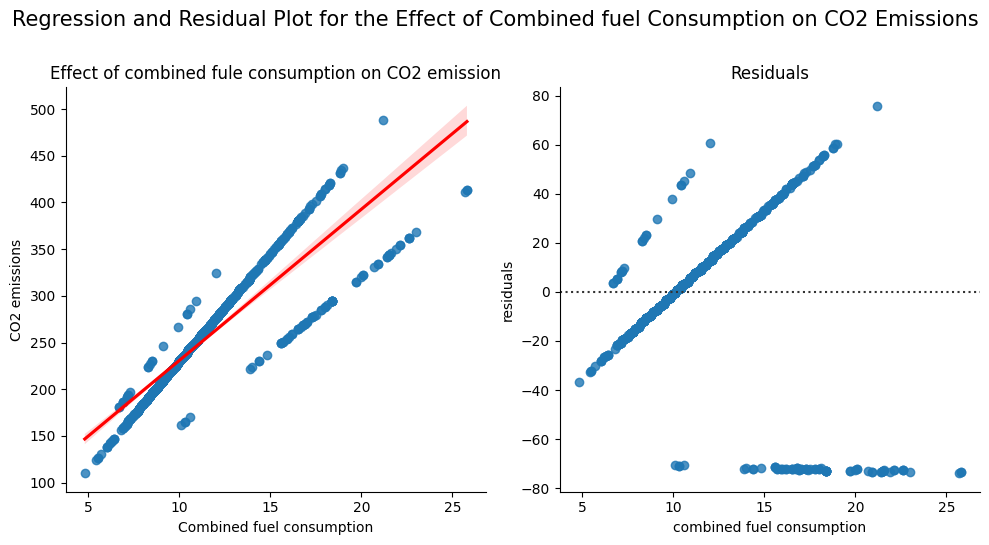

In [98]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,5))

sns.regplot(x = X_train, y = y_train,line_kws = ({"color":"red"}) , ax = ax1)
sns.residplot(x = X_train, y = y_train, ax = ax2)

ax1.set_title("Effect of combined fule consumption on CO2 emission")
ax2.set_title("Residuals")

ax1.set_xlabel("Combined fuel consumption")
ax1.set_ylabel("CO2 emissions")

ax2.set_xlabel("combined fuel consumption")
ax2.set_ylabel("residuals")

sns.despine()
plt.tight_layout()

plt.suptitle("Regression and Residual Plot for the Effect of Combined fuel Consumption on CO2 Emissions", fontsize = 15, y = 1.08 )

plt.show()

Text(0.5, 1.0, 'Effect of Combined Fuel Consumption on CO2 Emissions')

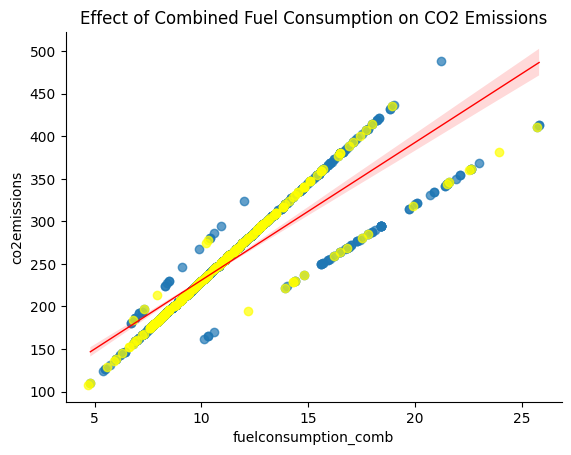

In [99]:
sns.regplot(x = X_train, y = y_train, line_kws = ({"color":"red", "linewidth":1}), scatter_kws = ({"alpha":.7}))
plt.scatter(X_test, y_test, color= "yellow", alpha = .7)
sns.despine()
plt.title("Effect of Combined Fuel Consumption on CO2 Emissions")

<p>The regression plot shows a clear positive linear relationship between combined fuel consumption and CO₂ emissions, confirming that vehicles with higher fuel consumption tend to produce higher emissions. The fitted regression line captures the overall upward trend reasonably well, and the previously obtained performance metrics (R² ≈ 0.79–0.81, MAE ≈ 20, RMSE ≈ 28) initially suggested that the linear regression model provided a good predictive fit on both the training and testing datasets. The similarity between training and testing metrics also indicated that the model generalized consistently and did not exhibit strong overfitting.

However, the residual plot reveals important limitations that were not fully visible from the numerical metrics alone. Ideally, residuals should be randomly scattered around zero with no visible structure. In this case, the residuals display several distinct diagonal bands and systematic patterns rather than a random distribution. This suggests that the relationship between fuel consumption and CO₂ emissions may not be perfectly linear and that the model is failing to capture some underlying structure in the data. The presence of clustered residual patterns may indicate omitted variables, discrete groupings in vehicle characteristics, or potential heteroscedasticity, where the variance of the errors changes across fuel consumption levels.

Although the model achieves relatively strong predictive performance statistically, the residual analysis suggests that the assumptions of simple linear regression are only partially satisfied. Therefore, while the model is acceptable as a first approximation and provides interpretable results, it may not fully capture the complexity of the relationship between fuel consumption and emissions. To improve the model, it would be recommended to include additional explanatory variables such as engine size, number of cylinders, vehicle class, or fuel type, and potentially explore multiple linear regression.</p>

<h2>Multiple Linear Regression</h2>

In [100]:
df

,modelyear,make,model,vehicleclass,enginesize,cylinders,transmission,fueltype,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1062,2014,VOLVO,XC60 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1063,2014,VOLVO,XC60 AWD,SUV - SMALL,3.2,6,AS6,X,13.2,9.5,11.5,25,264
1064,2014,VOLVO,XC70 AWD,SUV - SMALL,3.0,6,AS6,X,13.4,9.8,11.8,24,271
1065,2014,VOLVO,XC70 AWD,SUV - SMALL,3.2,6,AS6,X,12.9,9.3,11.3,25,260


In [101]:
df_corr = df.copy()

In [102]:
df_corr2 = df_corr.drop(["modelyear", "make", "model",	"vehicleclass", "transmission", "fueltype"], axis = 1)

In [103]:
df_corr2.dtypes

enginesize                  float64
cylinders                     int64
fuelconsumption_city        float64
fuelconsumption_hwy         float64
fuelconsumption_comb        float64
fuelconsumption_comb_mpg      int64
co2emissions                  int64
dtype: object

In [104]:
df_corr2.corr()

,enginesize,cylinders,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
enginesize,1.000000,0.934011,0.832225,0.778746,0.819482,-0.808554,0.874154
cylinders,0.934011,1.000000,0.796473,0.724594,0.776788,-0.770430,0.849685
fuelconsumption_city,0.832225,0.796473,1.000000,0.965718,0.995542,-0.935613,0.898039
fuelconsumption_hwy,0.778746,0.724594,0.965718,1.000000,0.985804,-0.893809,0.861748
fuelconsumption_comb,0.819482,0.776788,0.995542,0.985804,1.000000,-0.927965,0.892129
fuelconsumption_comb_mpg,-0.808554,-0.770430,-0.935613,-0.893809,-0.927965,1.000000,-0.906394
co2emissions,0.874154,0.849685,0.898039,0.861748,0.892129,-0.906394,1.000000


In [105]:
df_corr2

,enginesize,cylinders,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
0,2.0,4,9.9,6.7,8.5,33,196
1,2.4,4,11.2,7.7,9.6,29,221
2,1.5,4,6.0,5.8,5.9,48,136
3,3.5,6,12.7,9.1,11.1,25,255
4,3.5,6,12.1,8.7,10.6,27,244
...,...,...,...,...,...,...,...
1062,3.0,6,13.4,9.8,11.8,24,271
1063,3.2,6,13.2,9.5,11.5,25,264
1064,3.0,6,13.4,9.8,11.8,24,271
1065,3.2,6,12.9,9.3,11.3,25,260


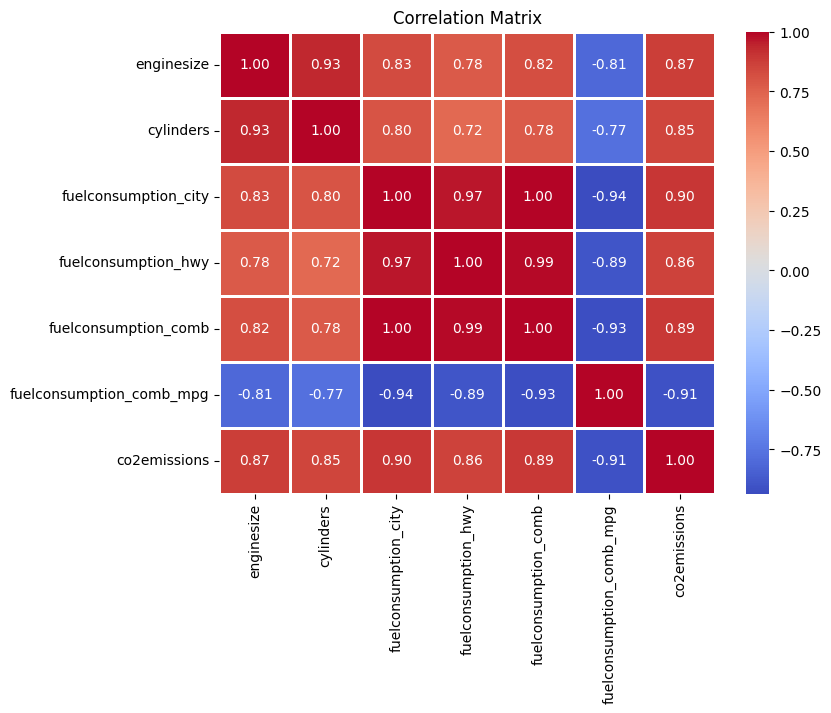

In [106]:
plt.figure(figsize=(8,6))
sns.heatmap(df_corr2.corr(), annot = True, cmap = "coolwarm", fmt = ".2f", linewidths = 1)
plt.title("Correlation Matrix")
plt.show()

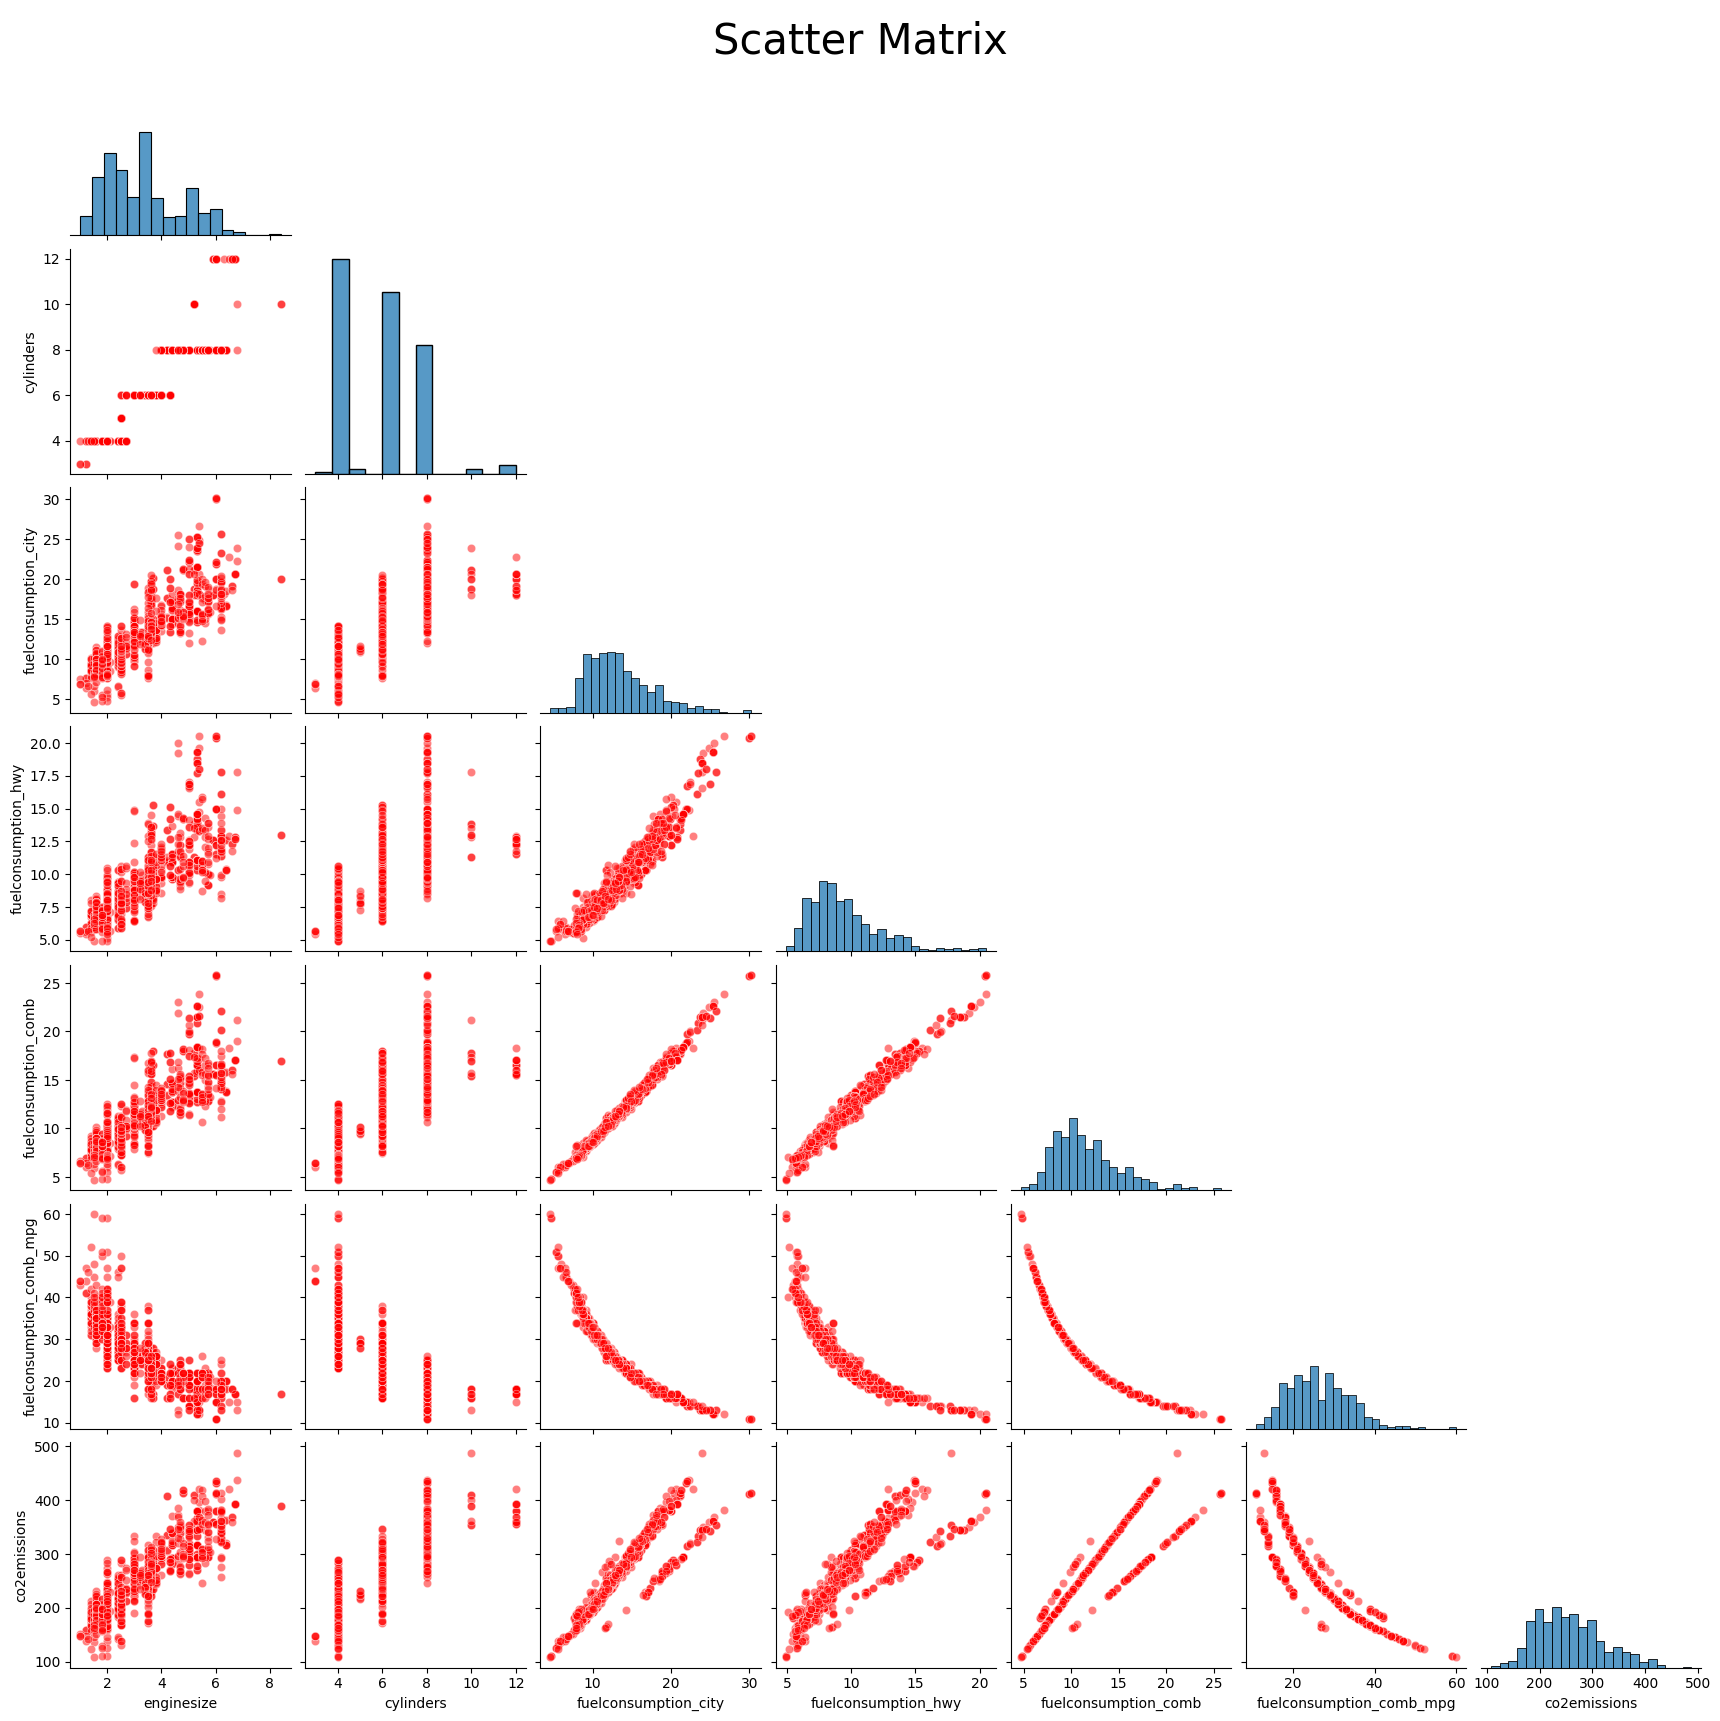

In [107]:
sns.pairplot(df_corr2, corner = True, plot_kws = ({"color":"red", "alpha": 0.5}))
plt.suptitle("Scatter Matrix", fontsize= 30)
plt.show()

In [108]:
df_variables = df_corr2.drop(["cylinders","fuelconsumption_city","fuelconsumption_hwy","fuelconsumption_comb"], axis = 1)
df_variables

,enginesize,fuelconsumption_comb_mpg,co2emissions
0,2.0,33,196
1,2.4,29,221
2,1.5,48,136
3,3.5,25,255
4,3.5,27,244
...,...,...,...
1062,3.0,24,271
1063,3.2,25,264
1064,3.0,24,271
1065,3.2,25,260


<h3>Sactter Matrix</h3>

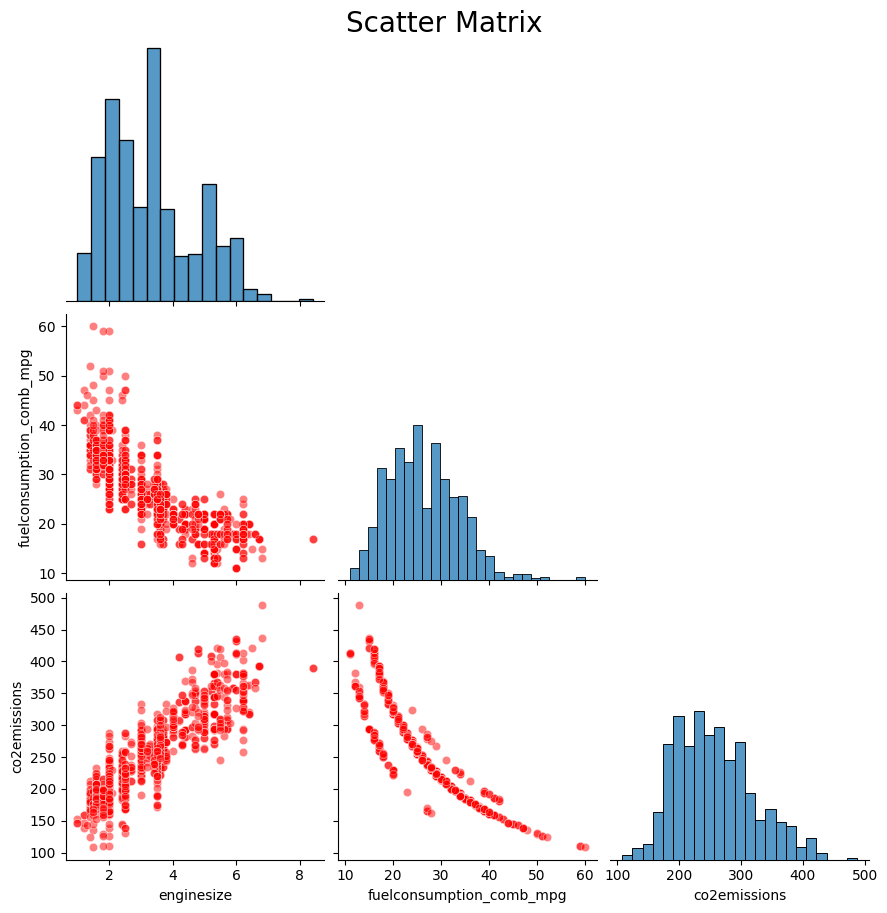

In [109]:
sns.pairplot(df_variables, corner = True, height=3, aspect = 1, plot_kws = ({"color":"red", "alpha": 0.5}))
plt.suptitle("Scatter Matrix", fontsize= 20, y = 1.01)
plt.show()

<h3>Standardize Features (Z-Score Normalization)</h3>
<p>\( z = \frac{x - \mu}{\sigma} \)</p>

In [110]:
df_variables.columns

Index(['enginesize', 'fuelconsumption_comb_mpg', 'co2emissions'], dtype='object')

In [111]:
X = df_variables[["enginesize", "fuelconsumption_comb_mpg"]]
y = df_variables['co2emissions']
X.describe()

,enginesize,fuelconsumption_comb_mpg
count,1067.000000,1067.000000
mean,3.346298,26.441425
std,1.415895,7.468702
min,1.000000,11.000000
25%,2.000000,21.000000
50%,3.400000,26.000000
75%,4.300000,31.000000
max,8.400000,60.000000


In [112]:
from sklearn.preprocessing import StandardScaler

ZNormalisation = StandardScaler()
X_standardized = ZNormalisation.fit_transform(X) 

In [113]:
pd.DataFrame(X_standardized).describe().round(2)

,0,1
count,1067.00,1067.00
mean,0.00,-0.00
std,1.00,1.00
min,-1.66,-2.07
25%,-0.95,-0.73
50%,0.04,-0.06
75%,0.67,0.61
max,3.57,4.50


<h3>Train Test Split </h3>

In [114]:
from sklearn.model_selection import train_test_split

X_standardized_train, X_standardized_test, y_train, y_test = train_test_split(X_standardized, y, test_size = 0.2, random_state = 42)

In [115]:
print(X_standardized_train.shape, X_standardized_test.shape)

(853, 2) (214, 2)


<h3>Multiple Linear Regresion Model</h3>

In [116]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model

LinearRegression()

In [117]:
model.fit(X_standardized_train, y_train)

LinearRegression()

In [118]:
a = model.coef_
b = model.intercept_
print(f"The Multiple Linear Regresison equation after standardization is: co2emissions = {a[0]:.2f}*enginesize + {a[1]:.2f}*fuelconsumption_comb_mpg + {b:.2f}")

The Multiple Linear Regresison equation after standardization is: co2emissions = 25.27*enginesize + -37.44*fuelconsumption_comb_mpg + 256.29


<h3>Unstandardize the Intercept and Coefficients </h3>

<p> When we train a linear regression model on standardized features, the model is actually fit in the transformed space where each feature is scaled as:
     \( z = \frac{x - \mu}{\sigma} \). In that space, the model has the form \( y = \beta_0 + \beta_1 z_1 + \beta_2 z_2 \), which expands to \( y = \beta_0 + \beta_1 \frac{x_1 - \mu_1}{\sigma_1} + \beta_2 \frac{x_2 - \mu_2}{\sigma_2} \). 
    However, we usually want the equivalent model in the original feature space, written as:
    \( y = a_1 x_1 + a_2 x_2 + b \). 
To transform back, we distribute the standardized terms:
    \( y = \beta_0 + \frac{\beta_1}{\sigma_1}x_1 - \frac{\beta_1 \mu_1}{\sigma_1} + \frac{\beta_2}{\sigma_2}x_2 - \frac{\beta_2 \mu_2}{\sigma_2} \). 
    Grouping terms gives the original form:
    \( y = a_1 x_1 + a_2 x_2 + b \), where the coefficients become \( a_i = \frac{\beta_i}{\sigma_i} \) and the intercept becomes \( b = \beta_0 - \sum_i \frac{\beta_i \mu_i}{\sigma_i} \). 

This shows that standardization changes the scale and shifts the intercept, and we recover the original parameters by undoing both effects mathematically. </p>

In [119]:
scaler_mean = ZNormalisation.mean_
scaler_std = ZNormalisation.scale_ #np.sqrt(std_scaler.var_)

original_coef_ = a/scaler_std
original_intercept_ = b - np.sum( (a*scaler_mean)/scaler_std)

print(f"Raw multiple linear regresison equation: co2emissions = {original_coef_[0]:.2f}*enginesize + {original_coef_[1]:.2f}*fuelconsumption_comb_mpg + {original_intercept_:.2f}")

Raw multiple linear regresison equation: co2emissions = 17.86*enginesize + -5.02*fuelconsumption_comb_mpg + 329.14


<h4>Graphical Representation of the Multiple Linear Regression</h4>

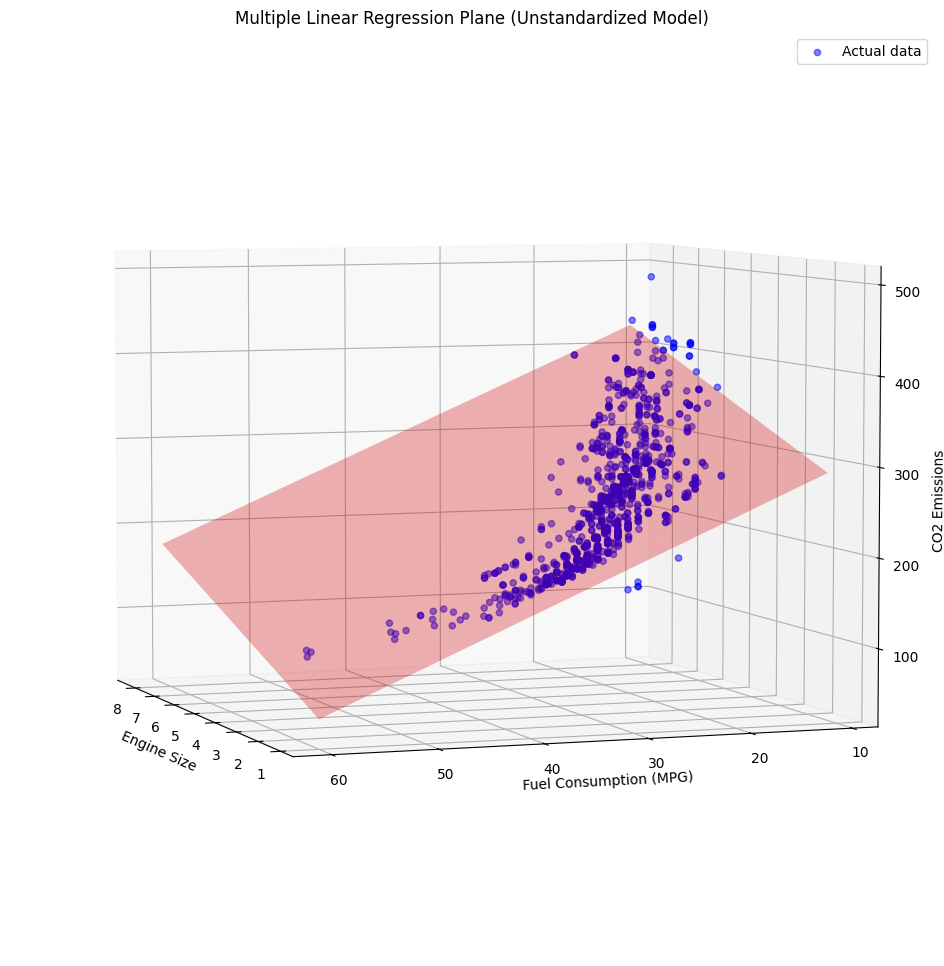

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Data (replace with your real dataset columns)
# -----------------------------
x1 = X["enginesize"]
x2 = X["fuelconsumption_comb_mpg"]
y = y  # co2emissions

# -----------------------------
# Model coefficients (UNSTANDARDIZED)
# -----------------------------
b0 = 329.14
b1 = 17.86
b2 = -5.02

# -----------------------------
# Create meshgrid for plane
# -----------------------------
x1_range = np.linspace(x1.min(), x1.max(), 20)
x2_range = np.linspace(x2.min(), x2.max(), 20)
X1, X2 = np.meshgrid(x1_range, x2_range)

# Regression plane equation
Y_pred = b0 + b1 * X1 + b2 * X2

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection='3d')

# Scatter actual data
ax.scatter(x1, x2, y, color='blue', alpha=0.5, label='Actual data')

# Regression plane
ax.plot_surface(X1, X2, Y_pred, color='red', alpha=0.3)

# Labels
ax.set_xlabel("Engine Size")
ax.set_ylabel("Fuel Consumption (MPG)")
ax.set_zlabel("CO2 Emissions")
ax.set_title("Multiple Linear Regression Plane (Unstandardized Model)")

ax.view_init(elev=5, azim=160)

plt.legend()
plt.show()

<h4>Graphical Representations Dimension by Dimension: Partial Regression Lines</h4>

Full multiple linear regression model:

<p>
\[
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2
\]
</p>

Isolate the effect of a single predictor by holding the other variable constant (set to (0)).

<p>
When plotting emissions against engine size, we fix:
\[
x_2 = 0 \; (\text{ignored})
\]
So the model becomes:
\[
y = \beta_0 + \beta_1 x_1
\]
</p>

<p>
This produces a straight line with slope \(\beta_1\) and intercept \(\beta_0\), representing the marginal effect of engine size on emissions.
</p>

<p>
Similarly, when plotting emissions against fuel consumption, we fix:
\[
x_1 = 0 \; (\text{ignored})
\]
So the model becomes:
\[
y = \beta_0 + \beta_2 x_2
\]
</p>

<p>
This yields another straight line with slope \(\beta_2\) and intercept \(\beta_0\), representing the isolated effect of fuel consumption on emissions.
</p>

<p>
In both cases, each line is a 2D cross-section of the original regression plane:
\[
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2
\]
showing the marginal contribution of one variable while the other is held constant.
</p>


<h5>Multiple Regression Equation:</h5>

In [121]:
enginesize = X_standardized_train[: , 0]
fuelconsumption_comb_mpg = X_standardized_train[:,1]
co2emissions_pred = a[0]*enginesize + a[1]*fuelconsumption_comb_mpg + b
#Fix fuelconsumption_comb_mpg to 0:
co2emissions_pred_engine = a[0]*enginesize + a[1]*0 + b
#Fix enginesize to 0:
co2emissions_pred_fuel = a[0]*0 + a[1]*fuelconsumption_comb_mpg + b

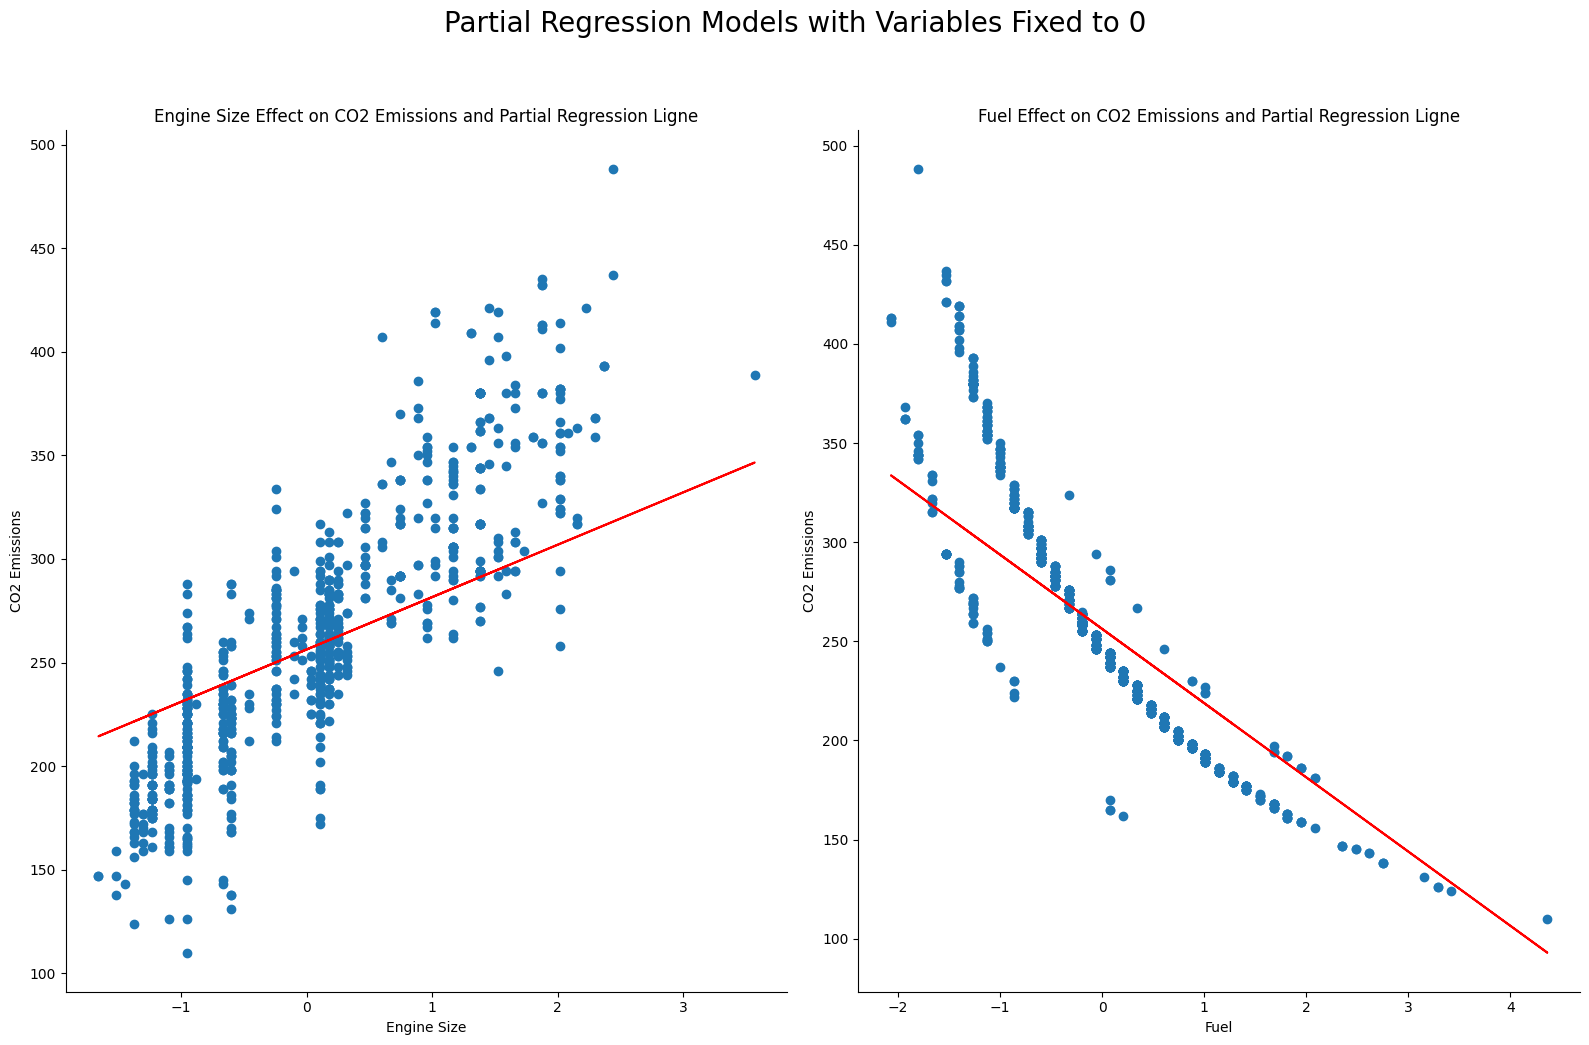

In [122]:
plt.figure(figsize=(16,10)) # 4:3 or 16:10

ax1 = plt.subplot(1,2,1)
ax1.scatter(X_standardized_train[:,0], y_train)
ax1.plot(X_standardized_train[:,0], co2emissions_pred_engine, color = "red")
ax1.set_title("Engine Size Effect on CO2 Emissions and Partial Regression Ligne")
ax1.set_xlabel("Engine Size")
ax1.set_ylabel("CO2 Emissions")

ax2 = plt.subplot(1,2,2)
ax2.scatter(X_standardized_train[:,1], y_train)
ax2.plot(X_standardized_train[:,1], co2emissions_pred_fuel, color = "red")
ax2.set_title("Fuel Effect on CO2 Emissions and Partial Regression Ligne")
ax2.set_xlabel("Fuel")
ax2.set_ylabel("CO2 Emissions")

plt.suptitle("Partial Regression Models with Variables Fixed to 0", fontsize=20, y = 1.04)

plt.tight_layout()
sns.despine()
plt.show()

In [123]:
enginesize = X_standardized_train[: , 0]
fuelconsumption_comb_mpg = X_standardized_train[:,1]

co2emissions_pred = a[0]*enginesize + a[1]*fuelconsumption_comb_mpg + b

#Fix fuelconsumption_comb_mpg to mean_fuel:
mean_fuel = np.mean(fuelconsumption_comb_mpg)
co2emissions_pred_engine_1 = a[0]*enginesize + a[1]*mean_fuel + b
#Fix enginesize to mean_eng:
mean_eng = np.mean(enginesize)
co2emissions_pred_fuel_2 = a[0]*mean_eng + a[1]*fuelconsumption_comb_mpg + b

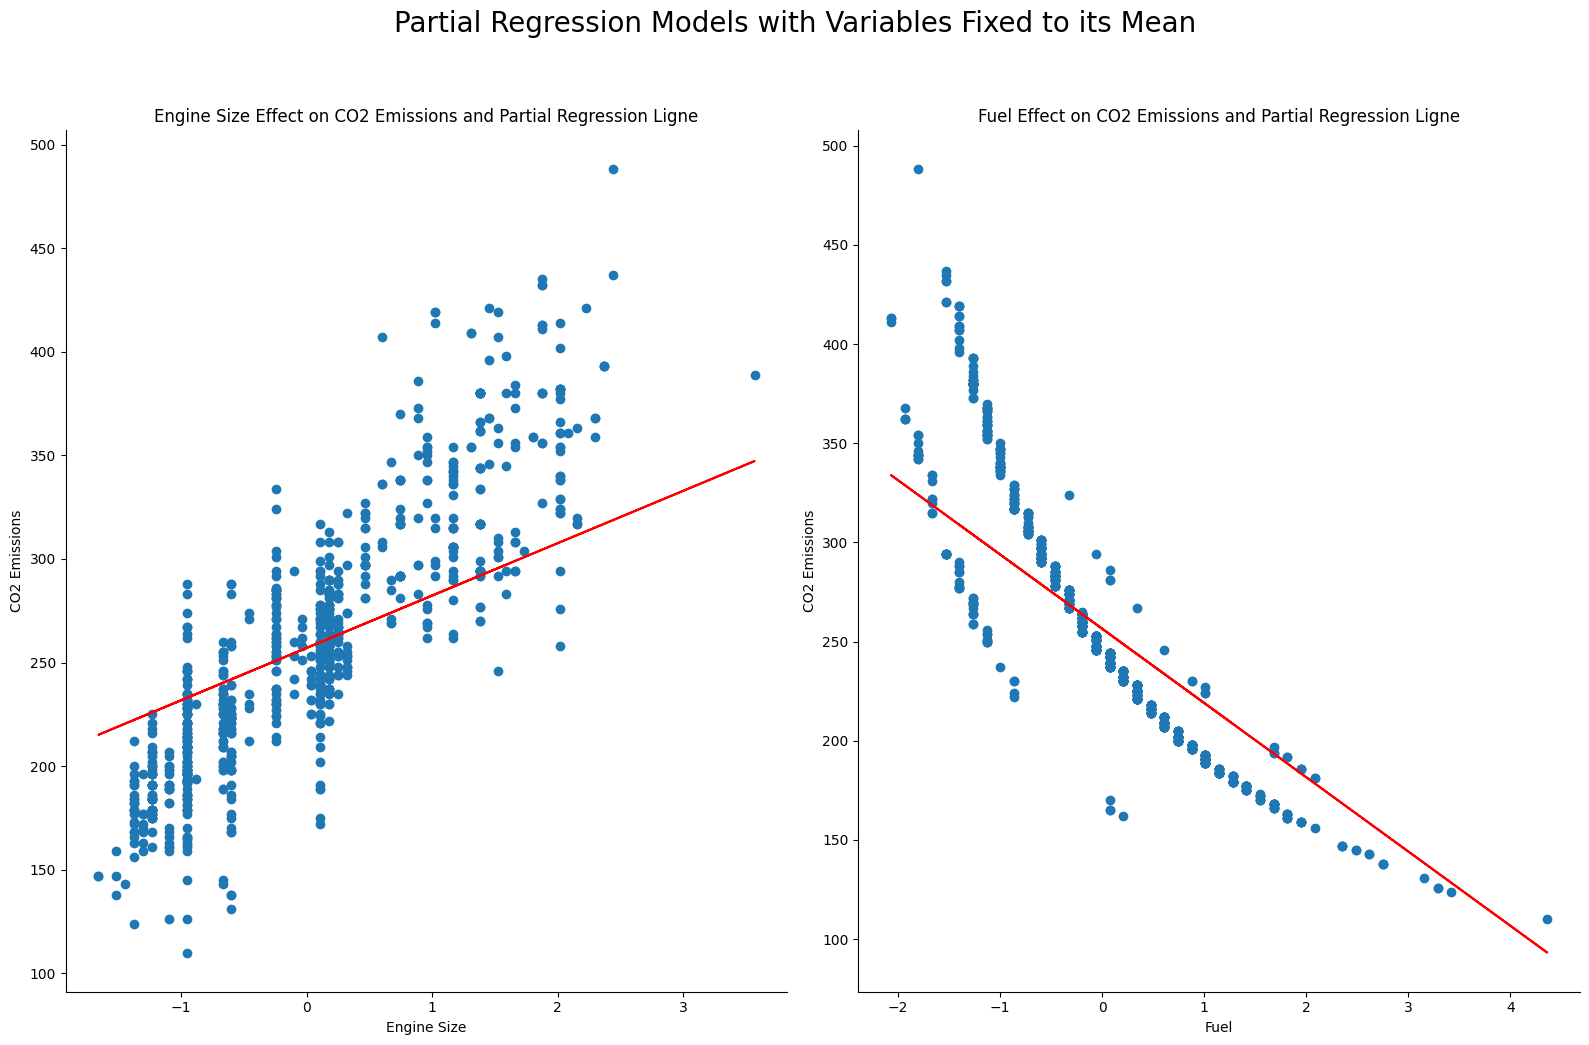

In [124]:
plt.figure(figsize=(16,10)) # 4:3 or 16:10

ax1 = plt.subplot(1,2,1)
ax1.scatter(X_standardized_train[:,0], y_train)
ax1.plot(X_standardized_train[:,0], co2emissions_pred_engine_1, color = "red")
ax1.set_title("Engine Size Effect on CO2 Emissions and Partial Regression Ligne")
ax1.set_xlabel("Engine Size")
ax1.set_ylabel("CO2 Emissions")

ax2 = plt.subplot(1,2,2)
ax2.scatter(X_standardized_train[:,1], y_train)
ax2.plot(X_standardized_train[:,1], co2emissions_pred_fuel_2, color = "red")
ax2.set_title("Fuel Effect on CO2 Emissions and Partial Regression Ligne")
ax2.set_xlabel("Fuel")
ax2.set_ylabel("CO2 Emissions")

plt.suptitle("Partial Regression Models with Variables Fixed to its Mean", fontsize=20, y = 1.04)

plt.tight_layout()
sns.despine()
plt.show()

<h4>Partail Residual Plots</h4>

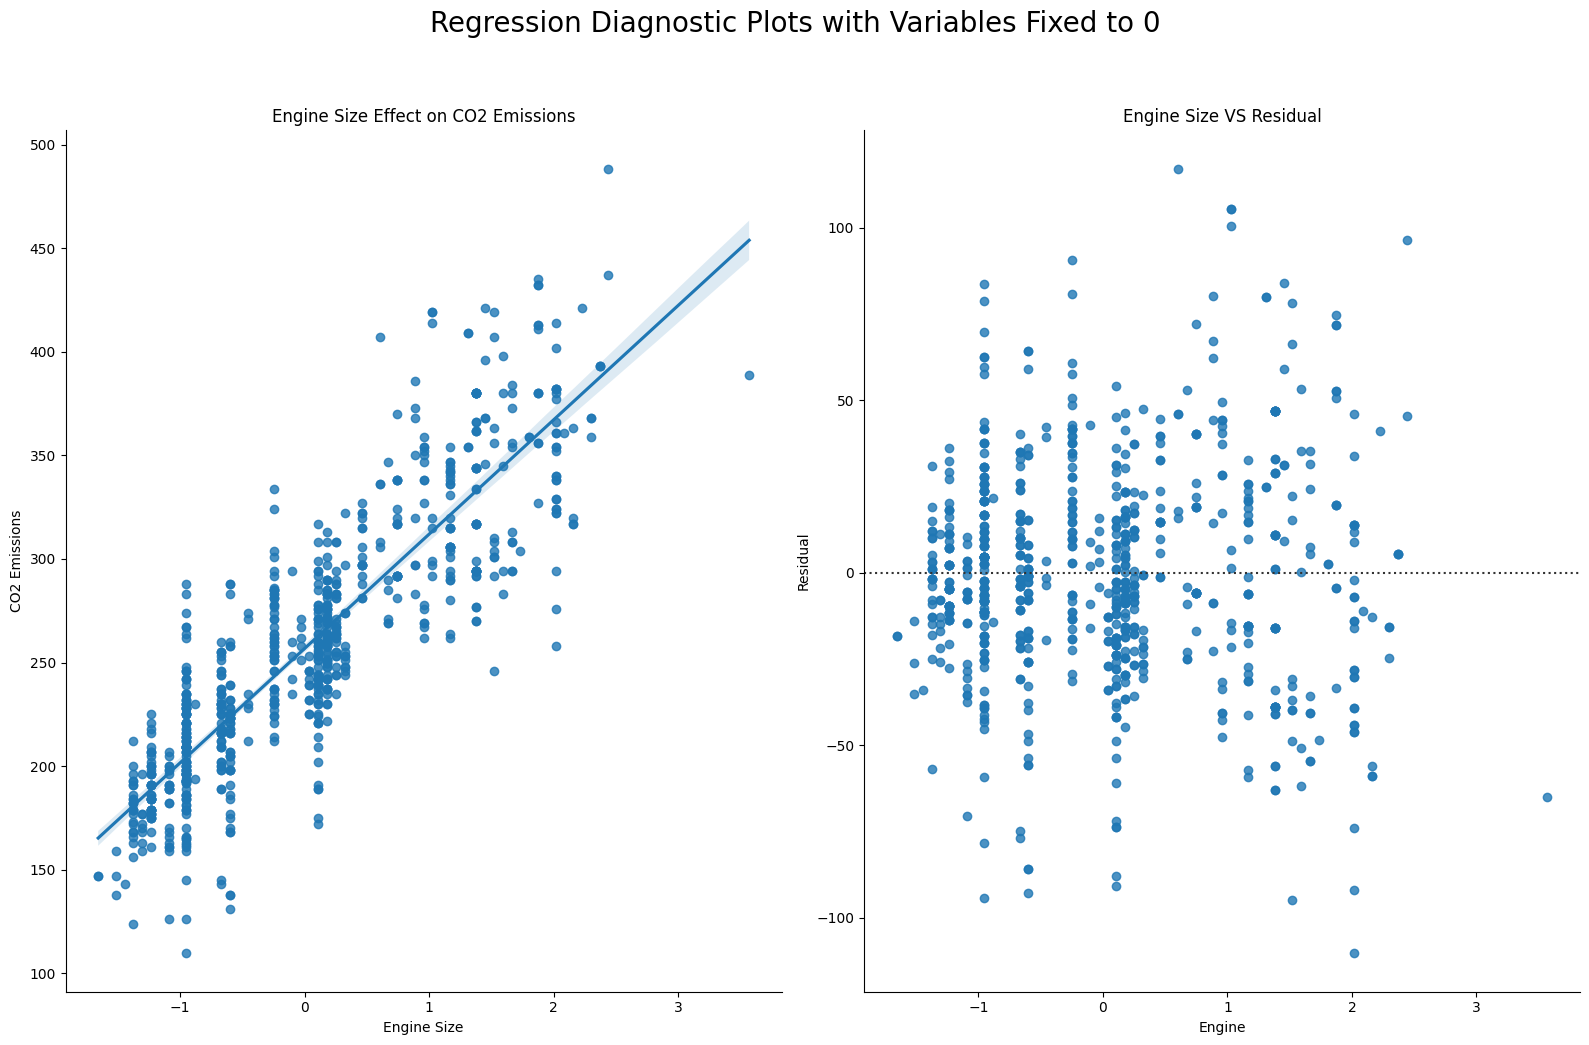

In [126]:
plt.figure(figsize=(16,10)) # 4:3 or 16:10

ax1 = plt.subplot(1,2,1)
sns.regplot(x=X_standardized_train[:,0], y=y_train, ax = ax1)
ax1.set_title("Engine Size Effect on CO2 Emissions")
ax1.set_xlabel("Engine Size")
ax1.set_ylabel("CO2 Emissions")

ax2 = plt.subplot(1,2,2)
sns.residplot(x=X_standardized_train[:,0],y= y_train, ax = ax2)
ax2.set_title("Engine Size VS Residual")
ax2.set_xlabel("Engine")
ax2.set_ylabel("Residual")

plt.suptitle("Regression Diagnostic Plots with Variables Fixed to 0", fontsize=20, y = 1.04)

plt.tight_layout()
sns.despine()
plt.show()

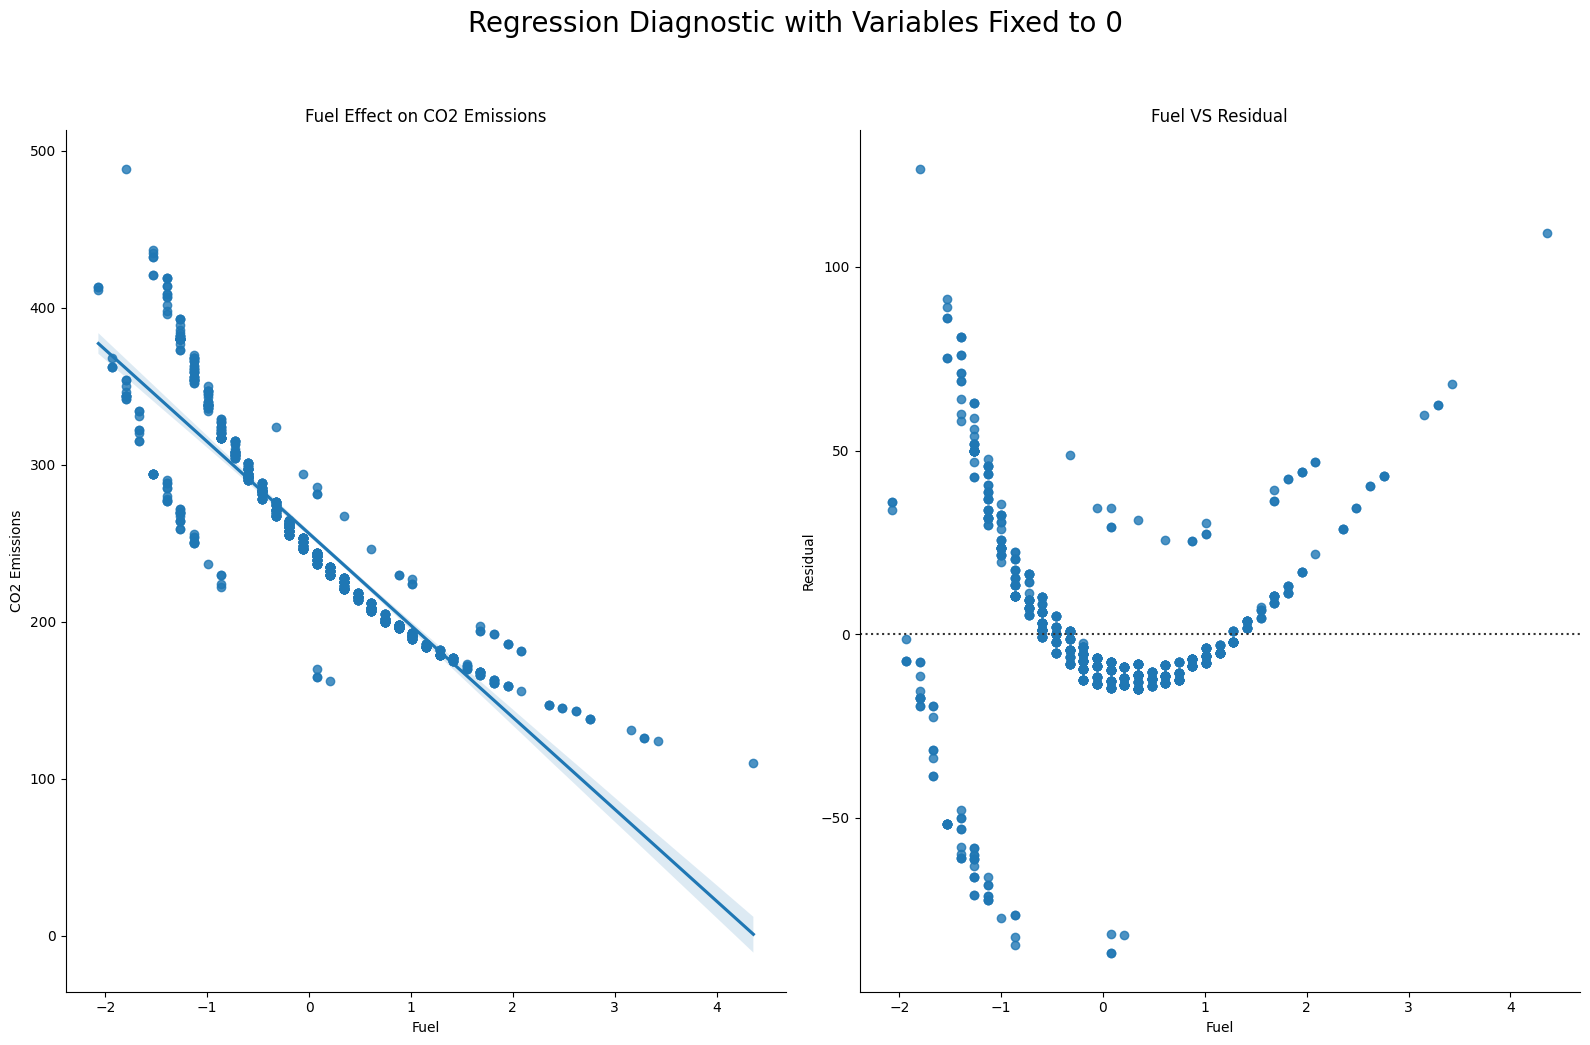

In [129]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))

x1 = X_standardized_train[:, 0]  # engine
x2 = X_standardized_train[:, 1]  # fuel
y = y_train

b0 = b
b1 = a[0]
b2 = a[1]

# =========================================================
# 1. SIMPLE REGRESSION (Fuel only)
# =========================================================
ax1 = plt.subplot(1,3,1)

sns.regplot(x=x2, y=y, ax=ax1)

ax1.set_title("1. Fuel vs CO2 (Simple Regression)")
ax1.set_xlabel("Fuel Consumption")
ax1.set_ylabel("CO2 Emissions")

# =========================================================
# 2. PARTIAL REGRESSION LINE (Fuel effect in full model)
# =========================================================
ax2 = plt.subplot(1,3,2)

mean_x1 = np.mean(x1)

x2_line = np.linspace(x2.min(), x2.max(), 100)
y_line = b0 + b1 * mean_x1 + b2 * x2_line

ax2.scatter(x2, y, alpha=0.4)
ax2.plot(x2_line, y_line, color='red', linewidth=2)

ax2.set_title("2. Partial Regression (Engine fixed at mean)")
ax2.set_xlabel("Fuel Consumption")
ax2.set_ylabel("CO2 Emissions")

# =========================================================
# 3. PARTIAL RESIDUAL PLOT (Fuel effect)
# =========================================================
ax3 = plt.subplot(1,3,3)

partial_residual_fuel = y - (b0 + b1 * x1)

ax3.scatter(x2, partial_residual_fuel, alpha=0.4)

ax3.plot(x2_line, b2 * x2_line, color='red', linewidth=2)

ax3.set_title("3. Partial Residual (Fuel effect)")
ax3.set_xlabel("Fuel Consumption")
ax3.set_ylabel("Partial Residuals")

plt.suptitle("Fuel Consumption Effect: Regression vs Partial vs Residual", fontsize=18)
plt.tight_layout()
sns.despine()
plt.show()

<p> <b>Simple regression:</b> The model assumes a single predictor \(x\) explains the response: \[ \hat{y} = \beta_0 + \beta_1 x \] The residuals are defined as: \[ r = y - \hat{y} \] A residual plot shows \(x\) versus \(r\), and is used to check whether the linear form is appropriate (a good model shows residuals randomly scattered around \(0\)). </p> <p> <b>Multiple regression:</b> With two predictors, the model becomes: \[ \hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 \] Residuals are: \[ r = y - (\beta_0 + \beta_1 x_1 + \beta_2 x_2) \] Residual plots show \(x_1\) vs \(r\) or \(x_2\) vs \(r\), and are used to check whether the model has captured all structure (a good model shows no pattern and values centered around \(0\)). </p> <p> <b>Partial regression (controlled effect view):</b> To isolate the effect of \(x_1\), we fix the other variable (often at its mean): \[ x_2 = \bar{x}_2 \] so the model becomes: \[ \hat{y}_{x_1} = \beta_0 + \beta_1 x_1 + \beta_2 \bar{x}_2 \] Similarly for \(x_2\): \[ x_1 = \bar{x}_1 \quad \Rightarrow \quad \hat{y}_{x_2} = \beta_0 + \beta_1 \bar{x}_1 + \beta_2 x_2 \] These give straight lines representing the effect of one variable while holding the other constant (a slice of the regression plane). </p> <p> <b>Partial residuals (isolated feature effect):</b> For \(x_1\), the partial residual is: \[ r^{(1)} = y - (\beta_0 + \beta_2 x_2) \] which simplifies to: \[ r^{(1)} = \beta_1 x_1 + \varepsilon \] Similarly for \(x_2\): \[ r^{(2)} = y - (\beta_0 + \beta_1 x_1) \] These plots show the relationship between one predictor and the response after removing the effect of the other predictor, revealing the clean contribution of each feature. </p>

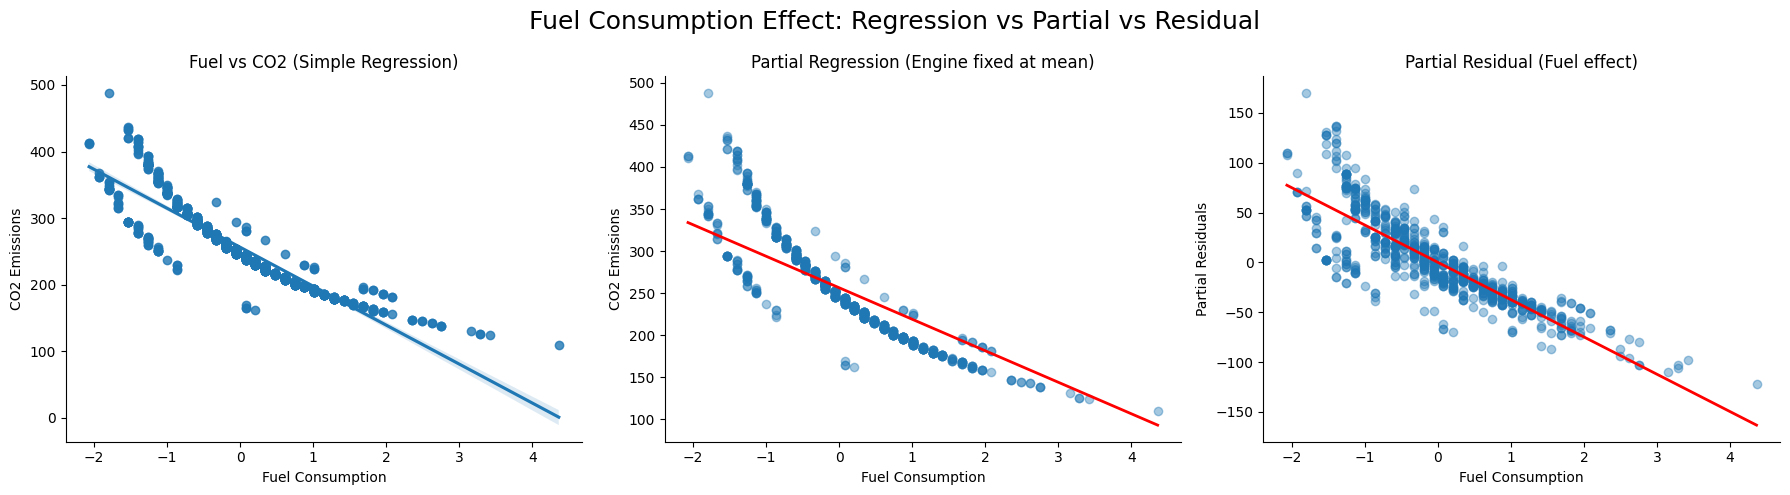

In [133]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,5))

x1, x2, y = X_standardized_train[:,0], X_standardized_train[:,1], y_train

b0, b1, b2 = b, a[0], a[1]

# =========================================================
# 1. SIMPLE REGRESSION (Fuel only)
# =========================================================
ax1 = plt.subplot(1,3,1); sns.regplot(x=x2, y=y, ax=ax1)
ax1.set_title("Fuel vs CO2 (Simple Regression)"); ax1.set_xlabel("Fuel Consumption"); ax1.set_ylabel("CO2 Emissions")

# =========================================================
# 2. PARTIAL REGRESSION LINE (Engine fixed at mean)
# =========================================================
ax2 = plt.subplot(1,3,2)

mean_x1 = np.mean(x1)

x2_line = np.linspace(x2.min(), x2.max(), 100)
y_line = b0 + b1*mean_x1 + b2*x2_line

ax2.scatter(x2, y, alpha=0.4)
ax2.plot(x2_line, y_line, color='red', linewidth=2)

ax2.set_title("Partial Regression (Engine fixed at mean)")
ax2.set_xlabel("Fuel Consumption")
ax2.set_ylabel("CO2 Emissions")

# =========================================================
# 3. PARTIAL RESIDUAL PLOT (Fuel effect)
# =========================================================
ax3 = plt.subplot(1,3,3)

partial_residual_fuel = y - (b0 + b1*x1)

ax3.scatter(x2, partial_residual_fuel, alpha=0.4)
ax3.plot(x2_line, b2*x2_line, color='red', linewidth=2)

ax3.set_title("Partial Residual (Fuel effect)")
ax3.set_xlabel("Fuel Consumption")
ax3.set_ylabel("Partial Residuals")

plt.suptitle("Fuel Consumption Effect: Regression vs Partial vs Residual", fontsize=18)
plt.tight_layout(); sns.despine(); plt.show()

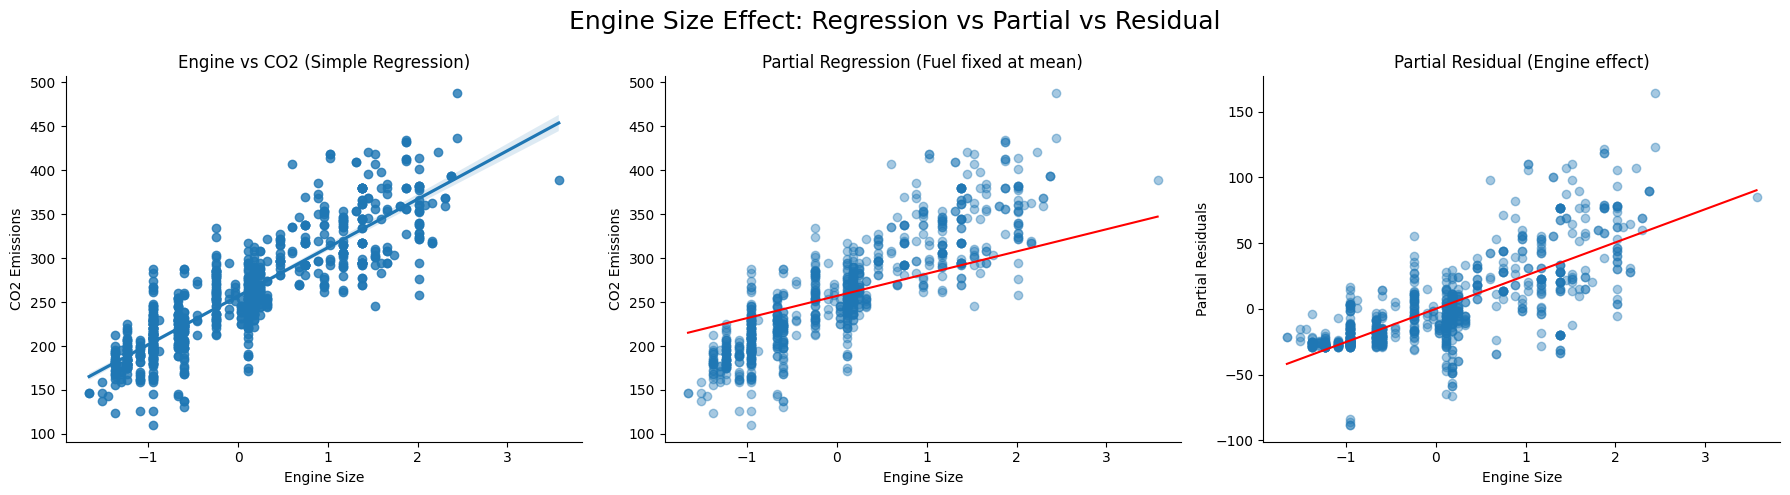

In [135]:
plt.figure(figsize=(18,5))

x1, x2, y = X_standardized_train[:,0], X_standardized_train[:,1], y_train
b0, b1, b2 = b, a[0], a[1]

# =========================================================
# 1. SIMPLE REGRESSION (Engine only)
# =========================================================
ax1 = plt.subplot(1,3,1); sns.regplot(x=x1, y=y, ax=ax1)
ax1.set_title("Engine vs CO2 (Simple Regression)")
ax1.set_xlabel("Engine Size"); ax1.set_ylabel("CO2 Emissions")

# =========================================================
# 2. PARTIAL REGRESSION (Engine effect, Fuel fixed)
# =========================================================
ax2 = plt.subplot(1,3,2)

mean_x2 = np.mean(x2)

x1_line = np.linspace(x1.min(), x1.max(), 100)
y_line = b0 + b1*x1_line + b2*mean_x2

ax2.scatter(x1, y, alpha=0.4)
ax2.plot(x1_line, y_line, color='red')

ax2.set_title("Partial Regression (Fuel fixed at mean)")
ax2.set_xlabel("Engine Size")
ax2.set_ylabel("CO2 Emissions")

# =========================================================
# 3. PARTIAL RESIDUAL (Engine effect)
# =========================================================
ax3 = plt.subplot(1,3,3)

partial_residual_engine = y - (b0 + b2*x2)

ax3.scatter(x1, partial_residual_engine, alpha=0.4)
ax3.plot(x1_line, b1*x1_line, color='red')

ax3.set_title("Partial Residual (Engine effect)")
ax3.set_xlabel("Engine Size")
ax3.set_ylabel("Partial Residuals")

plt.suptitle("Engine Size Effect: Regression vs Partial vs Residual", fontsize=18)
plt.tight_layout(); sns.despine(); plt.show()